[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ChrisW09/Python-for-AI-Driven-Automation/blob/main/fast_track/02_control_structures.ipynb)

# 📓 Notebook 2 (fast track) — Control Structures: Automating Decisions

> **Module:** Python Fundamentals · **Estimated time:** 35–45 min · **Difficulty:** Beginner

In Notebook 1 you learned how to **store** values. Now you'll teach Python to **act on** them — to make decisions, repeat work, and handle the messy reality of real-world data without crashing.

This is where Python starts to feel like *automation*. The same patterns you learn here — branching, looping, catching errors — are the bones of every data pipeline, every ticket-triage script, every retry loop around an API call. By the end of this notebook you will have written a small rules engine, a batch processor, and a defensive data-cleaning loop.

## 🎯 Learning objectives

By the end of this notebook you can:

1. Read and write Python's **indentation-based block syntax** confidently.
2. Branch on conditions with `if / elif / else` — the workhorse of any rules engine.
3. Combine conditions with `and`, `or`, `not`, and chained comparisons.
4. Iterate with `for` loops over both counters (`range`) and real data.
5. Repeat work with `while` loops, including safe retry/backoff patterns.
6. Control loop flow with `break` and `continue`.
7. Catch and handle errors gracefully with `try / except`.
8. Build a tiny end-to-end ticket-triage pipeline.

## ✅ Prerequisites

Notebook 1 (variables, types, arithmetic, f-strings).

> 🏎️ **You're on the fast track.** This is a trimmed version of the canonical [`01_foundations/02_control_structures.ipynb`](../01_foundations/02_control_structures.ipynb) — Control structures. The deepest Stretch exercises (A and B) and the 🎁 Bonus mini-project have been removed to keep the notebook under ~90 minutes; the harder Stretch C and D are kept. Open the canonical version once you want the deeper material.

---


## 1. Indentation — the "shape" of code

Most languages use braces `{ … }` to group code. Python uses **indentation**: lines that belong to the same block must start in the same column.

```
if score >= 80:
····print("Auto-approve")        ← 4 spaces in → inside the if
····send_email(user)             ← also inside
print("All done.")               ← back to column 0 → outside the if
```

Rules of thumb:

- The standard is **4 spaces** per level. Don't mix spaces and tabs.
- A "block-opening" line ends in `:` (e.g. `if x > 0:`, `for i in range(3):`, `def f():`).
- The block ends when indentation goes back to the previous level.

Most editors (including Colab) insert 4 spaces automatically when you press Tab after a `:` line.

In [1]:
confidence = 0.92

if confidence > 0.8:
    print("✅ Auto-approve this answer")
    print(f"   (confidence = {confidence:.0%})")
print("After the if-block (always runs).")


✅ Auto-approve this answer
   (confidence = 92%)
After the if-block (always runs).


> ⚠️ **IndentationError** is the single most common error new Python users see. If you see it, look at the column where each line *starts*. The usual culprit is mixed tabs and spaces.

## 2. `if / elif / else` — building a rules engine

The structure mirrors how product teams describe automation rules:

> *"If the model is very confident, auto-respond. Otherwise if it's somewhat confident, suggest a draft. Otherwise route to a human."*

In [2]:
# A two-way decision: do we send or hold?
score = 0.62

if score >= 0.5:
    print("➡️  Send the automated reply")
else:
    print("🛑  Route to a human reviewer")


➡️  Send the automated reply


In [3]:
# Multi-way decision — a triage rules engine for an AI support bot
def route_ticket(confidence):
    if confidence >= 0.90:
        return "auto-respond"
    elif confidence >= 0.70:
        return "draft-for-agent"
    elif confidence >= 0.40:
        return "human-only"
    else:
        return "needs-clarification"

# Try a few confidence scores
for c in [0.95, 0.78, 0.55, 0.30]:
    print(f"  confidence={c:.2f}  →  {route_ticket(c)}")


  confidence=0.95  →  auto-respond
  confidence=0.78  →  draft-for-agent
  confidence=0.55  →  human-only
  confidence=0.30  →  needs-clarification


**How Python evaluates `elif`.** Python checks branches *in order* and runs the **first** one whose condition is true. The rest are skipped.

> ⚠️ **Order matters.** If you wrote `confidence >= 0.40` first, *every* high-confidence ticket would fall into the "human-only" branch. As a rule of thumb, in a tiered rule like this go from the **most restrictive** condition to the **least**.

> 🎯 **Intuition.** Think of `if/elif/else` as a fall-through staircase. As soon as a step is "true", you step off; lower steps are never checked.

### Comparison and logical operators — your decision toolkit

| Operator | Meaning            | Example          | Result   |
|----------|--------------------|------------------|----------|
| `==`     | equal              | `5 == 5`         | `True`   |
| `!=`     | not equal          | `5 != 3`         | `True`   |
| `<`      | less than          | `3 < 5`          | `True`   |
| `>`      | greater than       | `3 > 5`          | `False`  |
| `<=`     | less or equal      | `5 <= 5`         | `True`   |
| `>=`     | greater or equal   | `5 >= 6`         | `False`  |
| `and`    | logical AND        | `True and False` | `False`  |
| `or`     | logical OR         | `True or False`  | `True`   |
| `not`    | logical NOT        | `not True`       | `False`  |
| `in`     | contains           | `"a" in "cat"`   | `True`   |

> 💡 **A common bug.** Writing `=` when you meant `==`. `=` *assigns*; `==` *compares*. `if x = 5:` is a syntax error in Python — a feature that stops the mistake.

In [4]:
# An eligibility rule for a "premium" customer
mrr_eur          = 1_250
account_age_days = 470
churn_risk       = False

# Combine with `and` / `or`
if mrr_eur >= 1_000 and account_age_days >= 365:
    print("💎 Eligible for the premium tier")

if mrr_eur >= 2_000 or account_age_days >= 730:
    print("🎁 Eligible for the loyalty discount")

# Negate with `not`
if not churn_risk:
    print("✅ Low churn risk — safe to upsell")

# Chained comparisons — the Pythonic "x between a and b"
sweet_spot = 500 <= mrr_eur <= 2000
print(f"In sweet-spot MRR band? {sweet_spot}")


💎 Eligible for the premium tier
✅ Low churn risk — safe to upsell
In sweet-spot MRR band? True


### Truthiness — when "falsy" values trip you up

Python treats several values as **falsy** in a boolean context: `0`, `0.0`, `""` (empty string), `None`, and empty containers like `[]`, `{}`, `()`. Everything else is **truthy**.

This is convenient (`if api_response:` reads as "if we got something back"), but watch out: `if score:` is `True` even when `score = -10`, but `False` when `score = 0`.

In [5]:
for value in [0, 1, -1, 0.0, "", "hi", None, [], [0], {}]:
    print(f"{repr(value):>6} → {'truthy' if value else 'falsy'}")


     0 → falsy
     1 → truthy
    -1 → truthy
   0.0 → falsy
    '' → falsy
  'hi' → truthy
  None → falsy
    [] → falsy
   [0] → truthy
    {} → falsy


### 🔬 What actually happens when you write `if x:`

`if x:` does **not** check whether `x` exists or is non-zero. It secretly calls **`bool(x)`** and branches on the result:

```text
if x:                 ┌──────────────┐
   ...        ───────▶│  bool(x) ?   │───── True  ──▶ run the block
                      └──────────────┘───── False ──▶ skip the block
```

So the real question Python asks is always *"is `bool(x)` True or False?"* Most values are **truthy**; only a short, fixed list is **falsy**:

| Falsy value | Why | Truthy counterpart |
|---|---|---|
| `False`    | the boolean itself      | `True` |
| `None`     | "no value"              | any object |
| `0`        | integer zero            | `1`, `-1`, `42` |
| `0.0`      | float zero              | `0.1`, `-3.0` |
| `''`       | empty string            | `'hi'`, `' '` (a space!) |
| `[]`       | empty list              | `[0]` (one item, even `0`) |
| `{}`       | empty dict              | `{'a': 1}` |
| `set()`    | empty set               | `{0}` |
| `()`       | empty tuple             | `(0,)` |

**The pattern:** "empty / zero / nothing" → falsy; everything else → truthy. This powers the idiom `if not items:` to mean *"if the list is empty"*.

In [6]:
# Proof: `if x:` is really `bool(x)`. Print bool() for every falsy value + a few truthy ones.
falsy   = [False, None, 0, 0.0, "", [], {}, set(), ()]
truthy  = [True, 1, -1, 0.1, "hi", " ", [0], {"a": 1}, {0}]

print("FALSY  (bool -> False):")
for v in falsy:
    print(f"  bool({repr(v):>7}) = {bool(v)}")

print("\nTRUTHY (bool -> True):")
for v in truthy:
    print(f"  bool({repr(v):>7}) = {bool(v)}")

# The `if not items:` idiom for "is this empty?"
items = []
if not items:
    print("\nitems is empty -> handle the empty case")


FALSY  (bool -> False):
  bool(  False) = False
  bool(   None) = False
  bool(      0) = False
  bool(    0.0) = False
  bool(     '') = False
  bool(     []) = False
  bool(     {}) = False
  bool(  set()) = False
  bool(     ()) = False

TRUTHY (bool -> True):
  bool(   True) = True
  bool(      1) = True
  bool(     -1) = True
  bool(    0.1) = True
  bool(   'hi') = True
  bool(    ' ') = True
  bool(    [0]) = True
  bool({'a': 1}) = True
  bool(    {0}) = True

items is empty -> handle the empty case


> ⚠️ **The trap: `if x:` is NOT the same as `if x is not None:`.** Truthiness lumps *empty* and *zero* in with `None`. If you only want to guard against a missing value, say so explicitly.

```python
count = 0           # a real, valid value — just happens to be zero
items = []          # a real, valid list — just happens to be empty

if count:           # ❌ FALSE for 0 — you skip a legitimate value!
    ...
if count is not None:   # ✅ TRUE for 0 — only None is rejected
    ...
```

> 🎯 **Rule of thumb.** Use `if x:` when "empty or zero counts as nothing" (the common case — `if results:`, `if not errors:`). Use `if x is not None:` when `0`, `0.0`, `''`, or `[]` are **valid** values you must keep and you're only filtering out a genuinely absent one (e.g. a default of `None`).

In [7]:
# ⚠️ The classic bug: 0 is falsy but it is NOT None.
def describe(score):
    # BUG: `if score:` treats a valid score of 0 as "missing"
    if score:
        return f"got a score: {score}"
    return "no score provided"

# FIX: only None means "missing"
def describe_fixed(score):
    if score is not None:
        return f"got a score: {score}"
    return "no score provided"

for s in [0.0, 0.92, None]:
    print(f"score={str(s):>5} | buggy: {describe(s):<22} | fixed: {describe_fixed(s)}")


score=  0.0 | buggy: no score provided      | fixed: got a score: 0.0
score= 0.92 | buggy: got a score: 0.92      | fixed: got a score: 0.92
score= None | buggy: no score provided      | fixed: no score provided


## 3. `for` loops — repeat the same operation over a batch

A `for` loop iterates over a *sequence*. Two patterns dominate:

1. **`range(...)`** — when you need to repeat *n* times or count.
2. **Iterate over a list / tuple / string** — when you have actual data.

In AI/automation work you'll spend most of your time in pattern 2: looping over rows, tickets, prompts, batches, or files.

In [8]:
# Pattern 1: range(stop)  — counts 0, 1, 2, ..., stop-1
print("range(5):")
for i in range(5):
    print(f"  i = {i}")

print("\nrange(1, 6):  (start inclusive, stop exclusive)")
for i in range(1, 6):
    print(f"  i = {i}")

print("\nrange(0, 11, 2):  (step)")
for i in range(0, 11, 2):
    print(f"  i = {i}")


range(5):
  i = 0
  i = 1
  i = 2
  i = 3
  i = 4

range(1, 6):  (start inclusive, stop exclusive)
  i = 1
  i = 2
  i = 3
  i = 4
  i = 5

range(0, 11, 2):  (step)
  i = 0
  i = 2
  i = 4
  i = 6
  i = 8
  i = 10


In [9]:
# Pattern 2: iterate over a batch of work items
prompts = [
    "Summarise this invoice",
    "Classify this email",
    "Extract dates from this contract",
    "Draft a polite refusal",
]
for p in prompts:
    print(f"  → sending prompt: {p!r}")


  → sending prompt: 'Summarise this invoice'
  → sending prompt: 'Classify this email'
  → sending prompt: 'Extract dates from this contract'
  → sending prompt: 'Draft a polite refusal'


### `enumerate` — when you also need the index

If you need both the position *and* the value, `enumerate` is your friend. This shows up constantly in batch processing where you want to label each item.

In [10]:
scores = [0.95, 0.78, 0.55, 0.30, 0.91]

for index, value in enumerate(scores):
    print(f"Ticket #{index}: confidence={value:.2f}")

print()
# Start counting at 1 if you prefer 1-based labels
for rank, value in enumerate(scores, start=1):
    print(f"  Rank {rank}: {value:.2f}")


Ticket #0: confidence=0.95
Ticket #1: confidence=0.78
Ticket #2: confidence=0.55
Ticket #3: confidence=0.30
Ticket #4: confidence=0.91

  Rank 1: 0.95
  Rank 2: 0.78
  Rank 3: 0.55
  Rank 4: 0.30
  Rank 5: 0.91


### Accumulating in a loop — the universal data pattern

Sums, counts, min, max, mean — they all share the same recipe: start a running value *outside* the loop, then update it *inside*.

In [11]:
# Daily latencies (seconds) for an LLM call — a week's worth
latencies = [1.84, 1.95, 2.10, 1.78, 2.32, 1.69, 2.04]

total = 0.0
n     = 0
peak  = 0.0

for lat in latencies:
    total += lat
    n     += 1
    if lat > peak:
        peak = lat

mean = total / n
print(f"Calls           : {n}")
print(f"Mean latency    : {mean:.3f}s")
print(f"Peak latency    : {peak:.3f}s")

# Python's built-ins handle this too — useful as a sanity check
print(f"\nDouble-check    : mean={sum(latencies)/len(latencies):.3f}s, peak={max(latencies)}s")


Calls           : 7
Mean latency    : 1.960s
Peak latency    : 2.320s

Double-check    : mean=1.960s, peak=2.32s


> 🎯 **Mental model.** A `for` loop over a sequence is a conveyor belt: each item walks past, you do something with it, and it disappears. You can take notes (accumulators) as items pass.

### Bonus — a loop that draws

The same conveyor belt can *draw*. One row of `█` characters per item turns the latency list into a chart — no plotting library needed (that arrives in Notebook 7).

In [12]:
days = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

print("LLM latency by day (one █ ≈ 0.1s)")
for i, lat in enumerate(latencies):
    bar  = "█" * round(lat * 10)
    flag = "  ← peak" if lat == peak else ""
    print(f"  {days[i]}  {bar} {lat}s{flag}")

LLM latency by day (one █ ≈ 0.1s)
  Mon  ██████████████████ 1.84s
  Tue  ████████████████████ 1.95s
  Wed  █████████████████████ 2.1s
  Thu  ██████████████████ 1.78s
  Fri  ███████████████████████ 2.32s  ← peak
  Sat  █████████████████ 1.69s
  Sun  ████████████████████ 2.04s


### The same bars, drawn for real

The ASCII bars above are charming, but matplotlib turns the very same `latencies` list into a proper chart with one call.

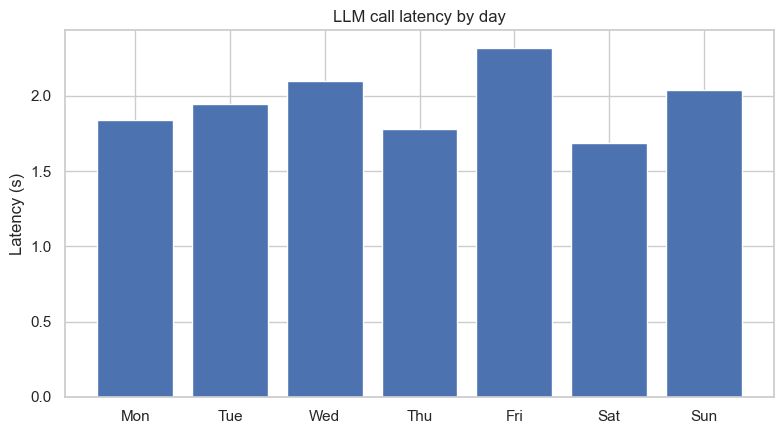

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
days = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(days, latencies, color='#4C72B0')
ax.set_ylabel("Latency (s)")
ax.set_title("LLM call latency by day")
plt.tight_layout()
plt.show()


**How to read it:** each bar is one day's latency — taller means slower; compare the heights to spot the bad days at a glance.

## 4. `while` loops — repeat *until* a condition becomes false

Use `while` when you don't know in advance how many iterations you need — only when to stop. The classic AI/automation use case is a **retry loop** around a flaky network call.

In [14]:
# Simulating a "call the API, retry on failure" loop
# (we don't actually call an API here — we just demo the pattern)
import random
random.seed(7)   # makes the demo reproducible

max_attempts = 5
attempt      = 0
success      = False

while attempt < max_attempts and not success:
    attempt += 1
    # Pretend the API succeeds 40% of the time
    success = random.random() < 0.4
    print(f"  attempt {attempt}: {'✅ ok' if success else '❌ fail'}")

print()
if success:
    print(f"Succeeded after {attempt} attempt(s).")
else:
    print(f"Gave up after {attempt} attempts.")


  attempt 1: ✅ ok

Succeeded after 1 attempt(s).


> ⚠️ **Infinite-loop trap.** A `while` loop *only* stops when the condition becomes false. Make sure the variable in the condition is actually being updated. In Colab/Jupyter you can stop a runaway cell with the ⏹️ button.

> 💡 **Pattern.** Two stop conditions joined by `and` — "keep trying *while* I haven't succeeded **and** I haven't burned through my budget" — is the safest shape for retries.

## 5. `break` and `continue` — fine-grained control

- **`break`** stops the loop entirely (exit early).
- **`continue`** skips the rest of *this* iteration and starts the next.

These let you avoid deeply nested `if`s and keep code readable.

In [15]:
# break: stop searching once you find a match
print("Finding the first low-confidence ticket:")
scores = [0.97, 0.94, 0.91, 0.42, 0.88]
for i, s in enumerate(scores):
    if s < 0.5:
        print(f"  Found at position {i}: {s}")
        break


Finding the first low-confidence ticket:
  Found at position 3: 0.42


In [16]:
# continue: skip noisy / malformed records
raw_durations = [4.2, -1.0, 7.1, 0.0, 5.8, -3.0, 6.5]   # negatives & zeros are bad data

clean_total = 0
n_valid     = 0
for d in raw_durations:
    if d <= 0:                # treat as invalid
        continue
    clean_total += d
    n_valid     += 1

print(f"Valid samples : {n_valid}")
print(f"Clean mean    : {clean_total / n_valid:.2f}s")


Valid samples : 4
Clean mean    : 5.90s


## 6. Nested loops — for table-shaped work

A loop *inside* another loop is useful for two-dimensional structures — for instance, running every prompt against every model in an A/B test.

In [17]:
# A tiny A/B grid: which (model × prompt) combinations should we test?
models  = ["gpt-4o-mini", "claude-haiku"]
prompts = ["P1: classify",  "P2: extract"]

print(f"{'model':<14} | {'prompt':<14}")
print("-" * 32)
for m in models:
    for p in prompts:
        print(f"{m:<14} | {p:<14}")


model          | prompt        
--------------------------------
gpt-4o-mini    | P1: classify  
gpt-4o-mini    | P2: extract   
claude-haiku   | P1: classify  
claude-haiku   | P2: extract   


## 7. Handling errors gracefully — `try / except`

Real data is messy. Real APIs go down. Instead of crashing the whole pipeline, you can **catch** the error and continue with the next item:

In [18]:
# Cleaning a column of "stringly typed" latencies from a log file
raw = ["1.84", "missing", "n/a", "2.10", "", "1.78", "2.32", "abc", "1.69"]

valid_latencies = []
for s in raw:
    try:
        v = float(s)                # may raise ValueError
        if v <= 0:
            raise ValueError("non-positive")
        valid_latencies.append(v)
        print(f"  OK   {s!r:>10}  →  {v:.2f}s")
    except ValueError as e:
        print(f"  SKIP {s!r:>10}  →  {e}")

print(f"\nKept {len(valid_latencies)} / {len(raw)} valid values")


  OK       '1.84'  →  1.84s
  SKIP  'missing'  →  could not convert string to float: 'missing'
  SKIP      'n/a'  →  could not convert string to float: 'n/a'
  OK       '2.10'  →  2.10s
  SKIP         ''  →  could not convert string to float: ''
  OK       '1.78'  →  1.78s
  OK       '2.32'  →  2.32s
  SKIP      'abc'  →  could not convert string to float: 'abc'
  OK       '1.69'  →  1.69s

Kept 5 / 9 valid values


> 💡 Catch **specific** exceptions, not a bare `except:` — bare excepts hide bugs you would actually want to know about. Common ones in data work: `ValueError`, `KeyError`, `TypeError`, `ZeroDivisionError`, `FileNotFoundError`, `requests.RequestException`.

## 8. Putting it all together — a tiny triage pipeline

Let's combine *everything* into one realistic mini-pipeline: route a small batch of incoming customer messages based on (a) a model confidence score, (b) whether the message contains escalation keywords, and (c) whether the customer is a VIP.

Notice how the same three patterns recur:

1. **a loop** over the batch,
2. **branching logic** for the rule,
3. **a `try / except`** to keep one malformed row from killing the run.

In [19]:
# Each ticket: (message, confidence_score, is_vip)
batch = [
    ("How do I export my data?",         0.94, False),
    ("ESCALATE: my account is locked!",  0.31, True),
    ("Can I get a refund?",              0.68, False),
    ("URGENT! billing wrong",            0.55, True),
    ("Hello",                            0.99, False),
    (None,                               0.40, False),     # a bad row
]

ESCALATION_WORDS = ("urgent", "escalate", "lawyer", "refund")

# Counters for the report
counts = {"auto-respond": 0, "draft-for-agent": 0, "human-only": 0, "errors": 0}

for msg, conf, is_vip in batch:
    try:
        # Step 1: a malformed message should be skipped
        text = msg.lower()              # raises AttributeError if msg is None

        # Step 2: classify by rule
        if any(w in text for w in ESCALATION_WORDS) or (is_vip and conf < 0.8):
            decision = "human-only"
        elif conf >= 0.9:
            decision = "auto-respond"
        else:
            decision = "draft-for-agent"

        counts[decision] += 1
        print(f"  {decision:<16}  conf={conf:.2f}  vip={is_vip}  {msg!r}")
    except AttributeError:
        counts["errors"] += 1
        print(f"  SKIP malformed row    msg={msg!r}")

# Step 3: a small summary
print("\nTriage summary:")
for bucket, n in counts.items():
    print(f"  {bucket:<16}: {n}")


  auto-respond      conf=0.94  vip=False  'How do I export my data?'
  human-only        conf=0.31  vip=True  'ESCALATE: my account is locked!'
  human-only        conf=0.68  vip=False  'Can I get a refund?'
  human-only        conf=0.55  vip=True  'URGENT! billing wrong'
  auto-respond      conf=0.99  vip=False  'Hello'
  SKIP malformed row    msg=None

Triage summary:
  auto-respond    : 2
  draft-for-agent : 0
  human-only      : 3
  errors          : 1


**What this little script demonstrates.**

- **`try/except`** to survive a malformed input (`None.lower()` would crash without it).
- **`any(... for ...)`** — a *generator expression* — to test "does any keyword match?" in one line.
- **a dictionary used as a counter** (we'll learn dictionaries properly in Notebook 3; for now think of it as a labelled bucket of counts).
- **rule precedence** — escalations and VIPs jump the queue *before* confidence is checked.

This is the entire skeleton of a production triage script. The only difference between this 25-line notebook cell and the production version is that the real one reads from a queue, talks to a model, and writes back to a database. The control flow is the same.

## 🧪 Practice exercises

### Exercise 1 — ⭐ Customer-tier rules

Given a list of monthly recurring revenues (MRR) in euros, count how many customers fall into each tier:

- **Enterprise**: MRR ≥ 5,000
- **Mid-market**: 1,000 ≤ MRR < 5,000
- **SMB**: 100 ≤ MRR < 1,000
- **Free**: MRR < 100

Print the counts and the percentage of customers in each tier.

In [20]:
mrr = [42, 1200, 87, 6500, 1850, 9300, 320, 75, 4100, 2700, 110, 5800]

# Your code here  👇


<details>
<summary>💡 <b>Solution</b></summary>

```python
tiers = {"Enterprise": 0, "Mid-market": 0, "SMB": 0, "Free": 0}

for v in mrr:
    if   v >= 5000: tiers["Enterprise"] += 1
    elif v >= 1000: tiers["Mid-market"] += 1
    elif v >=  100: tiers["SMB"]        += 1
    else:           tiers["Free"]       += 1

total = len(mrr)
for name, n in tiers.items():
    print(f"  {name:<11}: {n:>2}  ({n / total:.1%})")
```

**Reasoning.** Same pattern as the triage example: a counter dictionary plus `if/elif/elif/else` with the **most restrictive condition first**. If you tried `v >= 100` first, every enterprise customer would be miscategorised as SMB.
</details>

### Exercise 2 — ⭐⭐ Clean a "messy" log

You have a list of raw values from a noisy log. Some entries are negative (sensor errors), some are strings ("n/a", "missing"), and some are valid floats. Build a cleaned list and compute the **mean** of the cleaned values.

In [21]:
raw_data = [23, -5, 45, "missing", 67, -12, 89, 34, "n/a", -3, 56, 78]

# Your code here  👇


<details>
<summary>💡 <b>Solution</b></summary>

```python
clean = []
for v in raw_data:
    # Skip non-numeric entries
    if not isinstance(v, (int, float)):
        continue
    # Skip negative readings
    if v < 0:
        continue
    clean.append(v)

mean = sum(clean) / len(clean)
print(f"Clean values : {clean}")
print(f"Mean         : {mean:.2f}")
```

**Reasoning.** Two `continue` statements act as filters. Only values that pass *both* checks are appended. We compute the mean only on the cleaned data — calling `mean` on the raw list would crash on the string entries.
</details>

### Exercise 3 — ⭐⭐ FizzBuzz, the classic

For numbers 1–20, print:
- `Fizz` if divisible by 3,
- `Buzz` if divisible by 5,
- `FizzBuzz` if divisible by **both** 3 and 5,
- otherwise the number itself.

Yes, it's the famous interview question. It's worth doing because it forces you to think about branch order — exactly the skill you need for any rules engine.

In [22]:
# Your code here  👇


<details>
<summary>💡 <b>Solution</b></summary>

```python
for n in range(1, 21):
    if n % 15 == 0:          # divisible by 3 AND 5
        print("FizzBuzz")
    elif n % 3 == 0:
        print("Fizz")
    elif n % 5 == 0:
        print("Buzz")
    else:
        print(n)
```

**Reasoning.** The "divisible by both" case **must** be checked first, otherwise `n % 3 == 0` triggers for every multiple of 15 and you never reach the FizzBuzz branch. Equivalent: `n % 3 == 0 and n % 5 == 0`.
</details>

### Exercise 4 — ⭐⭐ Retry with exponential backoff

A function `call_api(attempt)` (provided below for demo) succeeds with probability `0.2 * attempt`. Write a `while` loop that retries up to 5 times, waiting `0.5 * 2**(attempt-1)` seconds between attempts (just *compute* the wait — don't actually sleep). Print each attempt's outcome and the cumulative wait time. Stop early on success.

In [23]:
import random
random.seed(11)

def call_api(attempt):
    # Demo only — succeeds with probability 0.2 * attempt
    return random.random() < 0.2 * attempt

# Your code here  👇


<details>
<summary>💡 <b>Solution</b></summary>

```python
attempt        = 0
max_attempts   = 5
total_wait_s   = 0.0
success        = False

while attempt < max_attempts and not success:
    attempt += 1
    success  = call_api(attempt)
    wait     = 0.5 * 2 ** (attempt - 1)
    if not success and attempt < max_attempts:
        total_wait_s += wait
        print(f"  attempt {attempt}: ❌ — waiting {wait:.2f}s before retry")
    elif success:
        print(f"  attempt {attempt}: ✅ on attempt {attempt}")
    else:
        print(f"  attempt {attempt}: ❌ — giving up")

print(f"\nTotal wait time: {total_wait_s:.2f}s")
```

**Why this matters.** Exponential backoff is the standard pattern for being a polite client to an API: short waits first, longer waits if the service is genuinely struggling. The doubling means you don't hammer a flaky service.
</details>

### Exercise 5 — ⭐⭐ Debug me 🐞

The loop below is *supposed* to count the negative readings in `data`, but it would run **forever**. Read it carefully, identify the bug, then rewrite a corrected version.

```python
data = [3, -1, 4, -5, 2, -7, 8]
count = 0
i = 0

while i < len(data):
    if data[i] < 0:
        count += 1
print(f"negatives: {count}")
```

> ⚠️ Do **not** copy-paste the buggy loop above and run it — it would hang the kernel. Write your fixed version in the cell below.

In [24]:
# 👇 Your fixed/corrected version goes here — write or paste it below.
data = [3, -1, 4, -5, 2, -7, 8]

# Write your corrected loop here  👇


<details>
<summary>💡 <b>Solution</b></summary>

The variable `i` is never incremented, so `i < len(data)` is always true. The fix:

```python
count = 0
i = 0

while i < len(data):
    if data[i] < 0:
        count += 1
    i += 1                  # ← the missing line

print(f"negatives: {count}")
```

**Better, more Pythonic version.** When in doubt, use a `for` loop — there is no index to forget to increment:

```python
count = sum(1 for x in data if x < 0)
print(f"negatives: {count}")
```

Whenever you find yourself manually managing an index in a `while`, ask yourself whether a `for` would do.
</details>

## 🧠 Stretch exercises

Two more applied exercises to deepen the material. Try them yourself before opening the solution.


### Stretch exercise C — ⭐⭐⭐ Tier discount calculator

A business has three pricing tiers based on monthly spend:

| Monthly spend | Discount |
|---|---|
| < \$100      | 0% |
| \$100–\$499  | 5% |
| \$500–\$999  | 10% |
| ≥ \$1000     | 15% |

Write a function `discount(spend)` that returns the **discount fraction** (e.g. `0.05`). Print the final price (`spend * (1 - discount)`) for each of these test values:

```python
for s in [42, 100, 500, 999, 1000, 5000]:
    ...
```

In [25]:
# Your code here  👇
def discount(spend):                 # type hints come later (NB 4)
    ...

for s in [42, 100, 500, 999, 1000, 5000]:
    pass


<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
def discount(spend: float) -> float:
    if spend < 100:    return 0.00
    if spend < 500:    return 0.05
    if spend < 1000:   return 0.10
    return 0.15

for s in [42, 100, 500, 999, 1000, 5000]:
    d = discount(s)
    print(f"${s:>5}  →  {d:>5.0%} off  →  ${s * (1-d):>8,.2f}")
```

**Reasoning.** Two patterns worth knowing. (1) The **`<` ladder** with early `return` is far cleaner than nested `if/elif/else` — each line reads as a single rule. (2) The format spec `{d:>5.0%}` renders `0.05` as `5%` and right-aligns it in a 5-char field, which makes a column of values line up nicely. Bonus tip: avoid `if A < x < B`-style chains in pricing logic — the half-open intervals `<` use here are exactly how spreadsheets and APIs usually express tier boundaries.
</details>

### Stretch exercise D — ⭐⭐⭐ Find the first 'urgent' ticket

You have a small queue of support tickets. Find the **first** ticket whose subject contains the word `"urgent"` (case-insensitive) and print its ID; if none, print `"no urgent tickets"`. Use a `for/else` loop — this is one of the few legitimate uses of `else` on a loop.

```python
tickets = [
    {"id": 101, "subject": "Cannot log in"},
    {"id": 102, "subject": "URGENT: payment failed"},
    {"id": 103, "subject": "Refund request"},
]
```

In [26]:
# Your code here  👇
tickets = [
    {"id": 101, "subject": "Cannot log in"},
    {"id": 102, "subject": "URGENT: payment failed"},
    {"id": 103, "subject": "Refund request"},
]
# ...


<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
for t in tickets:
    if "urgent" in t["subject"].lower():
        print(f"first urgent ticket: #{t['id']}")
        break
else:
    print("no urgent tickets")
```

**Reasoning.** Python's loop-`else` runs only if the loop completed *without* hitting `break`. That's exactly the semantics of "I searched the whole list and didn't find what I needed," which is why `for/else` is the natural shape of a *find-first* search. Compare with the alternatives — a sentinel flag (`found = False; ... if not found: print(...)`) is two extra lines, and `next((... for ...), None)` is concise but harder for newcomers to read. Use the tool that fits.
</details>

## 🧠 Key takeaways

1. **Indentation defines blocks** — 4 spaces, never mix tabs.
2. `if / elif / else` runs **the first true branch**, in order. Order matters — most restrictive condition first.
3. `for` iterates over a sequence; use `range()` for counters, `enumerate()` when you need indices.
4. `while` repeats until a condition becomes false — make sure that variable changes inside the loop, and protect retries with a max-attempts guard.
5. `break` exits a loop entirely; `continue` skips to the next iteration.
6. **Accumulator pattern**: initialise outside the loop, update inside. Works for sum, count, min, max, peak, …
7. Wrap risky operations in `try / except` and catch *specific* exception types.
8. The skeleton of every automation pipeline is: **loop → branch → handle errors → record outcome**.

## ✅ Self-assessment

- [ ] Write an `if/elif/else` rule with at least 3 branches in the right order
- [ ] Combine conditions with `and`, `or`, `not` and chained comparisons
- [ ] Iterate with `for ... in range(...)` and `for ... in some_list`
- [ ] Use `enumerate` when you need both index and value
- [ ] Write a `while` loop with a max-attempts guard so it cannot run forever
- [ ] Use `break` and `continue` purposefully
- [ ] Catch a specific exception with `try / except` and keep the rest of the loop running
- [ ] Explain the four "buckets" in the triage example and how their rules interact

## 🚀 Next step

Continue with **Notebook 3 (fast track) — Lists, Sequences & Dictionaries**, where you'll store and manipulate the collections of records (tickets, logs, customers) that drive every analysis.